In [1]:
import pandas as pd
from pathlib import Path

base = Path("qgis_project")
paths = {
    "aspect": base / "aspect.csv",
    "slope": base / "slope.csv",
    "vegetation": base / "vegetation.csv",
}

missing = [p for p in paths.values() if not p.exists()]
if missing:
    raise FileNotFoundError(f"Missing files in qgis_project: {', '.join(str(m) for m in missing)}")

aspect_df = pd.read_csv(paths["aspect"])
slope_df = pd.read_csv(paths["slope"])
vegetation_df = pd.read_csv(paths["vegetation"])

print(f"Loaded aspect: {len(aspect_df)} rows, slope: {len(slope_df)} rows, vegetation: {len(vegetation_df)} rows")

Loaded aspect: 43145 rows, slope: 43145 rows, vegetation: 6224 rows


In [2]:
aspect_df = aspect_df[aspect_df['value'] != -9999.0]
slope_df = slope_df[slope_df['value'] != -9999.0]
vegetation_df = vegetation_df[vegetation_df['value'] != 65535]

In [3]:
# Join aspect_df and slope_df on matching x and y coordinates
print("Before join:")
print(f"  Aspect dataframe: {len(aspect_df)} rows")
print(f"  Slope dataframe: {len(slope_df)} rows")

# Perform inner join on x and y columns
# Rename value columns to distinguish between aspect and slope values
aspect_slope_df = pd.merge(
    aspect_df.rename(columns={'value': 'aspect_value'}),
    slope_df.rename(columns={'value': 'slope_value'}),
    on=['x', 'y'],
    how='inner'
)

print(f"\nAfter join:")
print(f"  Combined dataframe: {len(aspect_slope_df)} rows")
print(f"  Columns: {aspect_slope_df.columns.tolist()}")

print("\nFirst 5 rows of joined data:")
print(aspect_slope_df.head())

Before join:
  Aspect dataframe: 18004 rows
  Slope dataframe: 18005 rows

After join:
  Combined dataframe: 18004 rows
  Columns: ['x', 'y', 'aspect_value', 'slope_value']

First 5 rows of joined data:
              x             y  aspect_value  slope_value
0 -1.316281e+07  4.048851e+06    258.420170     1.842283
1 -1.316181e+07  4.049787e+06    233.180830     9.814027
2 -1.316215e+07  4.054874e+06    203.662920    22.884270
3 -1.316322e+07  4.057144e+06     98.623566    20.707176
4 -1.316503e+07  4.054680e+06    122.746120    33.658474


In [4]:
# Join the combined aspect_slope_df with vegetation_df on matching x and y coordinates
print("Before joining with vegetation:")
print(f"  Aspect-Slope dataframe: {len(aspect_slope_df)} rows")
print(f"  Vegetation dataframe: {len(vegetation_df)} rows")

# Perform inner join with vegetation data
# Rename the vegetation value column to distinguish it
all_data_df = pd.merge(
    aspect_slope_df,
    vegetation_df.rename(columns={'value': 'vegetation_value'}),
    on=['x', 'y'],
    how='inner'
)

print(f"\nAfter joining with vegetation:")
print(f"  Final combined dataframe: {len(all_data_df)} rows")
print(f"  Columns: {all_data_df.columns.tolist()}")

print("\nFirst 5 rows of complete joined data:")
print(all_data_df.head())

print("\nData summary:")
print(f"  Aspect values range: {all_data_df['aspect_value'].min():.2f} to {all_data_df['aspect_value'].max():.2f}")
print(f"  Slope values range: {all_data_df['slope_value'].min():.2f} to {all_data_df['slope_value'].max():.2f}")
print(f"  Vegetation values range: {all_data_df['vegetation_value'].min()} to {all_data_df['vegetation_value'].max()}")

Before joining with vegetation:
  Aspect-Slope dataframe: 18004 rows
  Vegetation dataframe: 2551 rows

After joining with vegetation:
  Final combined dataframe: 0 rows
  Columns: ['x', 'y', 'aspect_value', 'slope_value', 'vegetation_value']

First 5 rows of complete joined data:
Empty DataFrame
Columns: [x, y, aspect_value, slope_value, vegetation_value]
Index: []

Data summary:
  Aspect values range: nan to nan
  Slope values range: nan to nan
  Vegetation values range: nan to nan


In [5]:
# Investigate why the join resulted in 0 matches
print("Investigating coordinate differences:")
print("\nAspect-Slope data coordinate ranges:")
print(f"  X range: {aspect_slope_df['x'].min():.2f} to {aspect_slope_df['x'].max():.2f}")
print(f"  Y range: {aspect_slope_df['y'].min():.2f} to {aspect_slope_df['y'].max():.2f}")

print("\nVegetation data coordinate ranges:")
print(f"  X range: {vegetation_df['x'].min():.2f} to {vegetation_df['x'].max():.2f}")
print(f"  Y range: {vegetation_df['y'].min():.2f} to {vegetation_df['y'].max():.2f}")

print("\nSample coordinates from aspect-slope data:")
print(aspect_slope_df[['x', 'y']].head())

print("\nSample coordinates from vegetation data:")
print(vegetation_df[['x', 'y']].head())

# Check if there are any overlapping coordinate ranges
x_overlap = (aspect_slope_df['x'].min() <= vegetation_df['x'].max()) and (vegetation_df['x'].min() <= aspect_slope_df['x'].max())
y_overlap = (aspect_slope_df['y'].min() <= vegetation_df['y'].max()) and (vegetation_df['y'].min() <= aspect_slope_df['y'].max())

print(f"\nCoordinate range overlap:")
print(f"  X ranges overlap: {x_overlap}")
print(f"  Y ranges overlap: {y_overlap}")

# Check for exact coordinate matches
print(f"\nChecking for any exact coordinate matches:")
common_coords = pd.merge(aspect_slope_df[['x', 'y']], vegetation_df[['x', 'y']], on=['x', 'y'], how='inner')
print(f"  Found {len(common_coords)} exact coordinate matches")

Investigating coordinate differences:

Aspect-Slope data coordinate ranges:
  X range: -13169898.81 to -13155976.52
  Y range: 4044847.38 to 4064730.32

Vegetation data coordinate ranges:
  X range: -13169704.16 to -13156054.16
  Y range: 4044895.08 to 4064695.08

Sample coordinates from aspect-slope data:
              x             y
0 -1.316281e+07  4.048851e+06
1 -1.316181e+07  4.049787e+06
2 -1.316215e+07  4.054874e+06
3 -1.316322e+07  4.057144e+06
4 -1.316503e+07  4.054680e+06

Sample coordinates from vegetation data:
               x            y
0  -1.316313e+07  4045915.075
2  -1.315917e+07  4054465.075
9  -1.316280e+07  4054885.075
15 -1.316661e+07  4056925.075
21 -1.315938e+07  4051975.075

Coordinate range overlap:
  X ranges overlap: True
  Y ranges overlap: True

Checking for any exact coordinate matches:
  Found 0 exact coordinate matches


In [6]:
# Try spatial join with coordinate rounding to handle precision differences
print("Attempting spatial join with coordinate rounding...")

# Round coordinates to handle precision differences
# Try different rounding levels to find matches
rounding_levels = [0, -1, -2]  # Round to integers, tens, hundreds

for round_level in rounding_levels:
    print(f"\nTrying rounding to {10**(-round_level) if round_level < 0 else 1} units...")
    
    # Create rounded versions of the dataframes
    aspect_slope_rounded = aspect_slope_df.copy()
    vegetation_rounded = vegetation_df.copy()
    
    aspect_slope_rounded['x_round'] = aspect_slope_df['x'].round(round_level)
    aspect_slope_rounded['y_round'] = aspect_slope_df['y'].round(round_level)
    
    vegetation_rounded['x_round'] = vegetation_df['x'].round(round_level)
    vegetation_rounded['y_round'] = vegetation_df['y'].round(round_level)
    
    # Try join with rounded coordinates
    test_join = pd.merge(
        aspect_slope_rounded[['x_round', 'y_round']],
        vegetation_rounded[['x_round', 'y_round']],
        on=['x_round', 'y_round'],
        how='inner'
    )
    
    print(f"  Found {len(test_join)} matches with rounding level {round_level}")
    
    if len(test_join) > 0:
        # Perform the actual join with this rounding level
        print(f"  Using rounding level {round_level} for final join...")
        
        all_data_df = pd.merge(
            aspect_slope_rounded.drop(columns=['x_round', 'y_round']),
            vegetation_rounded.rename(columns={'value': 'vegetation_value'}).drop(columns=['x_round', 'y_round']),
            left_on=[aspect_slope_rounded['x'].round(round_level), aspect_slope_rounded['y'].round(round_level)],
            right_on=[vegetation_rounded['x'].round(round_level), vegetation_rounded['y'].round(round_level)],
            how='inner'
        )
        
        print(f"  Final joined dataframe: {len(all_data_df)} rows")
        if len(all_data_df) > 0:
            print(f"  Columns: {all_data_df.columns.tolist()}")
            print("\n  First 5 rows:")
            print(all_data_df.head())
        break

Attempting spatial join with coordinate rounding...

Trying rounding to 1 units...
  Found 1 matches with rounding level 0
  Using rounding level 0 for final join...
  Final joined dataframe: 1 rows
  Columns: ['key_0', 'key_1', 'x_x', 'y_x', 'aspect_value', 'slope_value', 'x_y', 'y_y', 'vegetation_value']

  First 5 rows:
        key_0      key_1           x_x           y_x  aspect_value  \
0 -13159594.0  4049365.0 -1.315959e+07  4.049365e+06         270.0   

   slope_value           x_y          y_y  vegetation_value  
0    10.407383 -1.315959e+07  4049365.075             36026  


In [7]:
# Create a proper spatial join using coordinate rounding
print("Creating final spatial join with coordinate rounding...")

# Since rounding to integers (level 0) worked, use that approach
# Create temporary columns with rounded coordinates
aspect_slope_for_join = aspect_slope_df.copy()
vegetation_for_join = vegetation_df.copy()

aspect_slope_for_join['x_round'] = aspect_slope_df['x'].round(0)
aspect_slope_for_join['y_round'] = aspect_slope_df['y'].round(0)

vegetation_for_join['x_round'] = vegetation_df['x'].round(0)
vegetation_for_join['y_round'] = vegetation_df['y'].round(0)
vegetation_for_join = vegetation_for_join.rename(columns={'value': 'vegetation_value'})

# Perform the join using the rounded coordinates
all_data_df = pd.merge(
    aspect_slope_for_join,
    vegetation_for_join[['x_round', 'y_round', 'vegetation_value']],
    on=['x_round', 'y_round'],
    how='inner'
)

# Remove the temporary rounding columns
all_data_df = all_data_df.drop(columns=['x_round', 'y_round'])

print(f"Final spatial join results:")
print(f"  Combined dataframe: {len(all_data_df)} rows")
print(f"  Columns: {all_data_df.columns.tolist()}")

print("\nFirst 10 rows of spatially joined data:")
print(all_data_df.head(10))

if len(all_data_df) > 0:
    print("\nData summary:")
    print(f"  Aspect values range: {all_data_df['aspect_value'].min():.2f} to {all_data_df['aspect_value'].max():.2f}")
    print(f"  Slope values range: {all_data_df['slope_value'].min():.2f} to {all_data_df['slope_value'].max():.2f}")
    print(f"  Vegetation values range: {all_data_df['vegetation_value'].min()} to {all_data_df['vegetation_value'].max()}")
else:
    print("No matches found even with coordinate rounding.")

Creating final spatial join with coordinate rounding...
Final spatial join results:
  Combined dataframe: 1 rows
  Columns: ['x', 'y', 'aspect_value', 'slope_value', 'vegetation_value']

First 10 rows of spatially joined data:
              x             y  aspect_value  slope_value  vegetation_value
0 -1.315959e+07  4.049365e+06         270.0    10.407383             36026

Data summary:
  Aspect values range: 270.00 to 270.00
  Slope values range: 10.41 to 10.41
  Vegetation values range: 36026 to 36026


In [8]:
buildings_df = pd.read_csv(Path("qgis_project") / "building_clip_processed.csv")

In [9]:
buildings_df

,fid,OBJECTID,CODE,BLD_ID,HEIGHT,ELEV,SOURCE,DATE_,STATUS,OLD_BLD_ID,AREA,Shape_Length,Shape_Area,aspect_mean,slope_mean,veg_mean,area_2,perimeter,xcoord,ycoord
0,1,1399842,Courtyard,NaN,NaN,NaN,Glendale: Merrick & Co,1992,Unchanged,NaN,101.959341,42.076875,101.959341,231.360488,0.905329,154.000000,101.959341,42.076875,6.479381e+06,1.881513e+06
1,2,1399843,Courtyard,NaN,NaN,NaN,Glendale: Merrick & Co,1992,Unchanged,NaN,235.600473,64.735237,235.600473,233.244637,3.043743,34231.266329,235.600473,64.735237,6.478275e+06,1.884290e+06
2,3,1399854,Courtyard,NaN,NaN,NaN,Glendale: LARIAC2,2008,Unchanged,NaN,2593.961633,299.095255,2593.961632,224.771942,5.966687,154.000000,2593.961632,299.095255,6.480000e+06,1.882902e+06
3,4,1399855,Courtyard,NaN,NaN,NaN,Glendale: Merrick & Co,1992,Unchanged,NaN,2847.383161,210.879243,2847.383162,265.117615,1.971596,154.000000,2847.383162,210.879243,6.479746e+06,1.877349e+06
4,5,1399860,Courtyard,NaN,NaN,NaN,Glendale: LARIAC2,2008,Unchanged,NaN,595.672069,99.907908,595.672070,178.698617,1.160151,154.000000,595.672070,99.907908,6.477956e+06,1.885221e+06
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
55261,55262,2249855,Building,202000058328,21.375901,2243.272332,LARIAC6,2020,Modified,GLEN55144,2737.096755,236.888742,2737.096754,247.097132,2.864807,1910.603478,2737.096754,236.888742,6.483039e+06,1.913235e+06
55262,55263,2249856,Building,202000058329,24.579900,2079.633051,LARIAC6,2020,Modified,GLEN54567,2986.693290,268.578860,2986.693290,264.650055,5.627166,154.000000,2986.693290,268.578860,6.481347e+06,1.913284e+06
55263,55264,2249858,Building,202000058331,18.270001,2259.767470,LARIAC6,2020,Modified,GLEN55157,3648.158179,277.558893,3648.158179,209.226501,12.918912,24267.638248,3648.158179,277.558893,6.483382e+06,1.913355e+06
55264,55265,2249859,Building,202000058332,12.509100,2338.537563,LARIAC6,2020,New,NaN,345.884860,83.507173,345.884860,168.819504,17.645345,37717.000000,345.884860,83.507173,6.484631e+06,1.913405e+06


In [10]:
# Examine the buildings dataframe structure
print("Buildings dataframe info:")
print(f"Shape: {buildings_df.shape}")
print(f"Columns: {buildings_df.columns.tolist()}")

print("\nFirst few rows:")
print(buildings_df.head())

print("\nData types:")
print(buildings_df.dtypes)

# Check for aspect, slope, and vegetation columns
aspect_cols = [col for col in buildings_df.columns if 'aspect' in col.lower()]
slope_cols = [col for col in buildings_df.columns if 'slope' in col.lower()]
veg_cols = [col for col in buildings_df.columns if 'veg' in col.lower() or 'vegetation' in col.lower()]

print(f"\nAspect-related columns: {aspect_cols}")
print(f"Slope-related columns: {slope_cols}")
print(f"Vegetation-related columns: {veg_cols}")

# Look for mean columns specifically
mean_cols = [col for col in buildings_df.columns if 'mean' in col.lower()]
print(f"Mean-related columns: {mean_cols}")

Buildings dataframe info:
Shape: (55266, 20)
Columns: ['fid', 'OBJECTID', 'CODE', 'BLD_ID', 'HEIGHT', 'ELEV', 'SOURCE', 'DATE_', 'STATUS', 'OLD_BLD_ID', 'AREA', 'Shape_Length', 'Shape_Area', 'aspect_mean', 'slope_mean', 'veg_mean', 'area_2', 'perimeter', 'xcoord', 'ycoord']

First few rows:
   fid  OBJECTID       CODE BLD_ID  HEIGHT  ELEV                  SOURCE  \
0    1   1399842  Courtyard    NaN     NaN   NaN  Glendale: Merrick & Co   
1    2   1399843  Courtyard    NaN     NaN   NaN  Glendale: Merrick & Co   
2    3   1399854  Courtyard    NaN     NaN   NaN       Glendale: LARIAC2   
3    4   1399855  Courtyard    NaN     NaN   NaN  Glendale: Merrick & Co   
4    5   1399860  Courtyard    NaN     NaN   NaN       Glendale: LARIAC2   

   DATE_     STATUS OLD_BLD_ID         AREA  Shape_Length   Shape_Area  \
0   1992  Unchanged        NaN   101.959341     42.076875   101.959341   
1   1992  Unchanged        NaN   235.600473     64.735237   235.600473   
2   2008  Unchanged        Na

In [11]:
# Analyze the distribution of each risk factor
print("Fire Risk Factor Analysis:")
print("=" * 50)

print("\nAspect Mean Statistics:")
print(f"Range: {buildings_df['aspect_mean'].min():.2f} to {buildings_df['aspect_mean'].max():.2f}")
print(f"Mean: {buildings_df['aspect_mean'].mean():.2f}")
print(f"Std: {buildings_df['aspect_mean'].std():.2f}")

print("\nSlope Mean Statistics:")
print(f"Range: {buildings_df['slope_mean'].min():.2f} to {buildings_df['slope_mean'].max():.2f}")
print(f"Mean: {buildings_df['slope_mean'].mean():.2f}")
print(f"Std: {buildings_df['slope_mean'].std():.2f}")

print("\nVegetation Mean Statistics:")
print(f"Range: {buildings_df['veg_mean'].min():.2f} to {buildings_df['veg_mean'].max():.2f}")
print(f"Mean: {buildings_df['veg_mean'].mean():.2f}")
print(f"Std: {buildings_df['veg_mean'].std():.2f}")

# Check for any missing values
print("\nMissing Values:")
print(f"Aspect: {buildings_df['aspect_mean'].isna().sum()}")
print(f"Slope: {buildings_df['slope_mean'].isna().sum()}")
print(f"Vegetation: {buildings_df['veg_mean'].isna().sum()}")

Fire Risk Factor Analysis:

Aspect Mean Statistics:
Range: 0.81 to 360.00
Mean: 203.36
Std: 53.29

Slope Mean Statistics:
Range: 0.04 to 43.24
Mean: 3.60
Std: 4.07

Vegetation Mean Statistics:
Range: 154.00 to 39174.60
Mean: 2420.97
Std: 7641.54

Missing Values:
Aspect: 17
Slope: 16
Vegetation: 50


In [12]:
import numpy as np

# Create fire risk scoring functions
def score_aspect(aspect):
    """
    Score aspect based on fire risk (1-5 scale)
    South-facing slopes (135-225 degrees) are highest risk due to sun exposure
    """
    if pd.isna(aspect):
        return 3  # Neutral score for missing data
    
    # South-facing slopes (135-225) = highest risk
    if 135 <= aspect <= 225:
        return 5
    # Southeast/Southwest (90-135, 225-270) = high risk
    elif (90 <= aspect < 135) or (225 < aspect <= 270):
        return 4
    # East/West (45-90, 270-315) = moderate risk
    elif (45 <= aspect < 90) or (270 < aspect <= 315):
        return 3
    # Northeast/Northwest (315-360/0-45) = lower risk
    else:
        return 2

def score_slope(slope):
    """
    Score slope based on fire risk (1-5 scale)
    Steeper slopes = higher fire risk due to faster fire spread
    """
    if pd.isna(slope):
        return 3  # Neutral score for missing data
    
    if slope >= 20:      # Very steep
        return 5
    elif slope >= 10:    # Steep  
        return 4
    elif slope >= 5:     # Moderate
        return 3
    elif slope >= 2:     # Gentle
        return 2
    else:                # Flat
        return 1

def score_vegetation(veg_value):
    """
    Score vegetation based on fire risk (1-5 scale)
    Higher vegetation values typically indicate denser/more flammable vegetation
    """
    if pd.isna(veg_value):
        return 3  # Neutral score for missing data
    
    # Use quantile-based scoring for vegetation
    # Higher vegetation values = higher fire risk
    if veg_value >= 10000:    # Very high vegetation
        return 5
    elif veg_value >= 5000:   # High vegetation
        return 4
    elif veg_value >= 1000:   # Moderate vegetation
        return 3
    elif veg_value >= 500:    # Low vegetation
        return 2
    else:                     # Minimal vegetation
        return 1

# Apply scoring functions
print("Calculating individual risk scores...")
buildings_df['aspect_risk'] = buildings_df['aspect_mean'].apply(score_aspect)
buildings_df['slope_risk'] = buildings_df['slope_mean'].apply(score_slope)
buildings_df['vegetation_risk'] = buildings_df['veg_mean'].apply(score_vegetation)

# Calculate composite fire risk score
# Weight: Slope (40%), Aspect (30%), Vegetation (30%)
buildings_df['fire_risk_score'] = (
    0.4 * buildings_df['slope_risk'] + 
    0.3 * buildings_df['aspect_risk'] + 
    0.3 * buildings_df['vegetation_risk']
).round(2)

# Convert composite score to 1-5 integer scale
buildings_df['fire_risk_category'] = pd.cut(
    buildings_df['fire_risk_score'], 
    bins=[0, 1.5, 2.5, 3.5, 4.5, 5.0], 
    labels=[1, 2, 3, 4, 5],
    include_lowest=True
).astype(int)

print("Fire risk scoring complete!")
print(f"\nRisk category distribution:")
print(buildings_df['fire_risk_category'].value_counts().sort_index())

Calculating individual risk scores...
Fire risk scoring complete!

Risk category distribution:
fire_risk_category
1      266
2    30299
3    20579
4     3555
5      567
Name: count, dtype: int64


In [36]:
buildings_df

,fid,OBJECTID,CODE,BLD_ID,HEIGHT,ELEV,SOURCE,DATE_,STATUS,OLD_BLD_ID,...,xcoord,ycoord,aspect_risk,slope_risk,vegetation_risk,fire_risk_score,fire_risk_category,cluster_id,cluster_risk_category,pca_cluster
0,1,1399842,Courtyard,NaN,NaN,NaN,Glendale: Merrick & Co,1992,Unchanged,NaN,...,6.479381e+06,1.881513e+06,4,1,1,1.9,2,0.0,3.0,NaN
1,2,1399843,Courtyard,NaN,NaN,NaN,Glendale: Merrick & Co,1992,Unchanged,NaN,...,6.478275e+06,1.884290e+06,4,2,5,3.5,3,3.0,5.0,NaN
2,3,1399854,Courtyard,NaN,NaN,NaN,Glendale: LARIAC2,2008,Unchanged,NaN,...,6.480000e+06,1.882902e+06,5,3,1,3.0,3,0.0,3.0,NaN
3,4,1399855,Courtyard,NaN,NaN,NaN,Glendale: Merrick & Co,1992,Unchanged,NaN,...,6.479746e+06,1.877349e+06,4,1,1,1.9,2,0.0,3.0,NaN
4,5,1399860,Courtyard,NaN,NaN,NaN,Glendale: LARIAC2,2008,Unchanged,NaN,...,6.477956e+06,1.885221e+06,5,1,1,2.2,2,0.0,3.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
55261,55262,2249855,Building,202000058328,21.375901,2243.272332,LARIAC6,2020,Modified,GLEN55144,...,6.483039e+06,1.913235e+06,4,2,3,2.9,3,0.0,3.0,0.0
55262,55263,2249856,Building,202000058329,24.579900,2079.633051,LARIAC6,2020,Modified,GLEN54567,...,6.481347e+06,1.913284e+06,4,3,1,2.7,3,0.0,3.0,0.0
55263,55264,2249858,Building,202000058331,18.270001,2259.767470,LARIAC6,2020,Modified,GLEN55157,...,6.483382e+06,1.913355e+06,5,4,5,4.6,5,1.0,4.0,0.0
55264,55265,2249859,Building,202000058332,12.509100,2338.537563,LARIAC6,2020,New,NaN,...,6.484631e+06,1.913405e+06,5,4,5,4.6,5,3.0,5.0,0.0


In [37]:
buildings_df.to_csv('logic_based_clustering.csv')

In [13]:
# Import libraries for unsupervised learning
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, calinski_harabasz_score
import matplotlib.pyplot as plt
import seaborn as sns

# Prepare the data for unsupervised learning
print("Preparing data for unsupervised learning...")

# Select features for clustering (excluding missing values)
feature_cols = ['aspect_mean', 'slope_mean', 'veg_mean']
cluster_data = buildings_df[feature_cols].dropna()

print(f"Original dataset: {len(buildings_df)} buildings")
print(f"Complete cases for clustering: {len(cluster_data)} buildings")
print(f"Features used: {feature_cols}")

# Display basic statistics
print("\nFeature statistics for clustering dataset:")
print(cluster_data.describe())

Preparing data for unsupervised learning...
Original dataset: 55266 buildings
Complete cases for clustering: 55206 buildings
Features used: ['aspect_mean', 'slope_mean', 'veg_mean']

Feature statistics for clustering dataset:
        aspect_mean    slope_mean      veg_mean
count  55206.000000  55206.000000  55206.000000
mean     203.355335      3.594547   2421.376134
std       53.283629      4.062108   7642.166349
min        0.808579      0.037508    154.000000
25%      178.553885      1.107071    154.000000
50%      203.188862      2.208652    154.000000
75%      234.491829      4.260999    154.000000
max      360.000000     43.239977  39174.601038


Scaling features for clustering...
Scaled feature statistics:
       aspect_scaled  slope_scaled    veg_scaled
count   55206.000000  5.520600e+04  55206.000000
mean        0.002976  4.394187e-01   2267.376134
std         0.952549  1.287952e+00   7642.166349
min        -3.617943 -6.883938e-01      0.000000
25%        -0.440398 -3.492727e-01      0.000000
50%         0.000000  7.040257e-17      0.000000
75%         0.559602  6.507273e-01      0.000000
max         2.803305  1.300960e+01  39020.601038


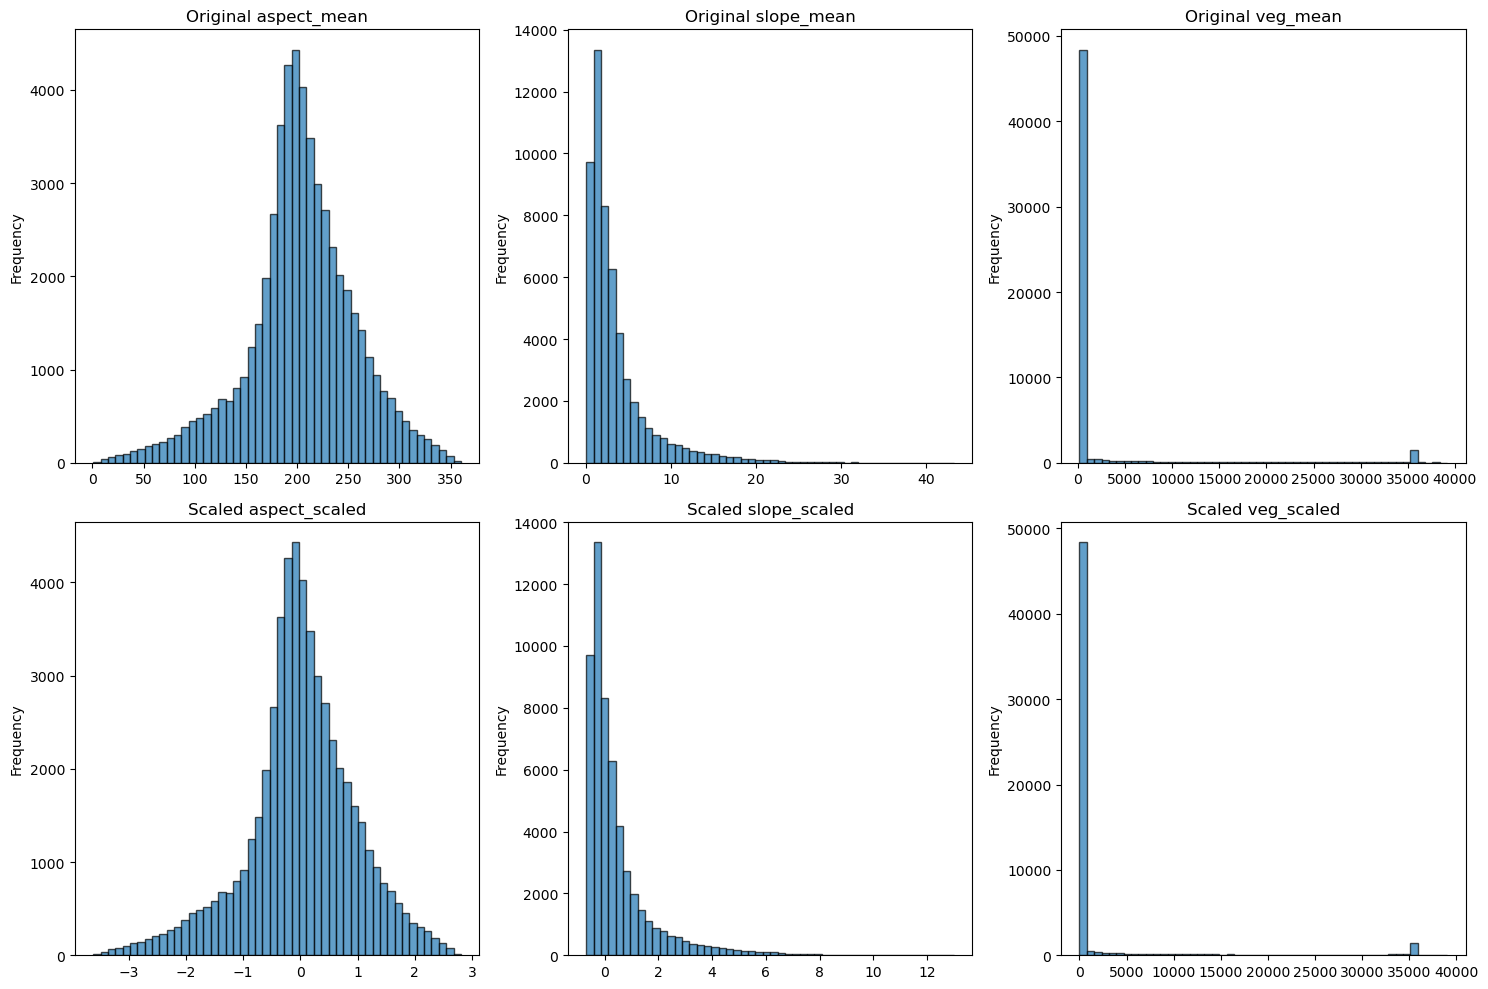


Data ready for clustering: (55206, 3)


In [14]:
# Data preprocessing and scaling
print("Scaling features for clustering...")

# Use RobustScaler due to potential outliers in vegetation data
scaler = RobustScaler()
cluster_data_scaled = scaler.fit_transform(cluster_data)

# Convert back to DataFrame for easier handling
cluster_df_scaled = pd.DataFrame(
    cluster_data_scaled, 
    columns=['aspect_scaled', 'slope_scaled', 'veg_scaled'],
    index=cluster_data.index
)

print("Scaled feature statistics:")
print(cluster_df_scaled.describe())

# Visualize feature distributions
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Original features
for i, col in enumerate(feature_cols):
    axes[0, i].hist(cluster_data[col], bins=50, alpha=0.7, edgecolor='black')
    axes[0, i].set_title(f'Original {col}')
    axes[0, i].set_ylabel('Frequency')

# Scaled features  
for i, col in enumerate(cluster_df_scaled.columns):
    axes[1, i].hist(cluster_df_scaled[col], bins=50, alpha=0.7, edgecolor='black')
    axes[1, i].set_title(f'Scaled {col}')
    axes[1, i].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

print(f"\nData ready for clustering: {cluster_data_scaled.shape}")

Finding optimal number of clusters...
Using sample of 5000 buildings for cluster optimization...
Testing k=2...
Testing k=3...
Testing k=4...
Testing k=5...
Testing k=6...
Testing k=7...
Testing k=8...
Testing k=9...
Testing k=10...


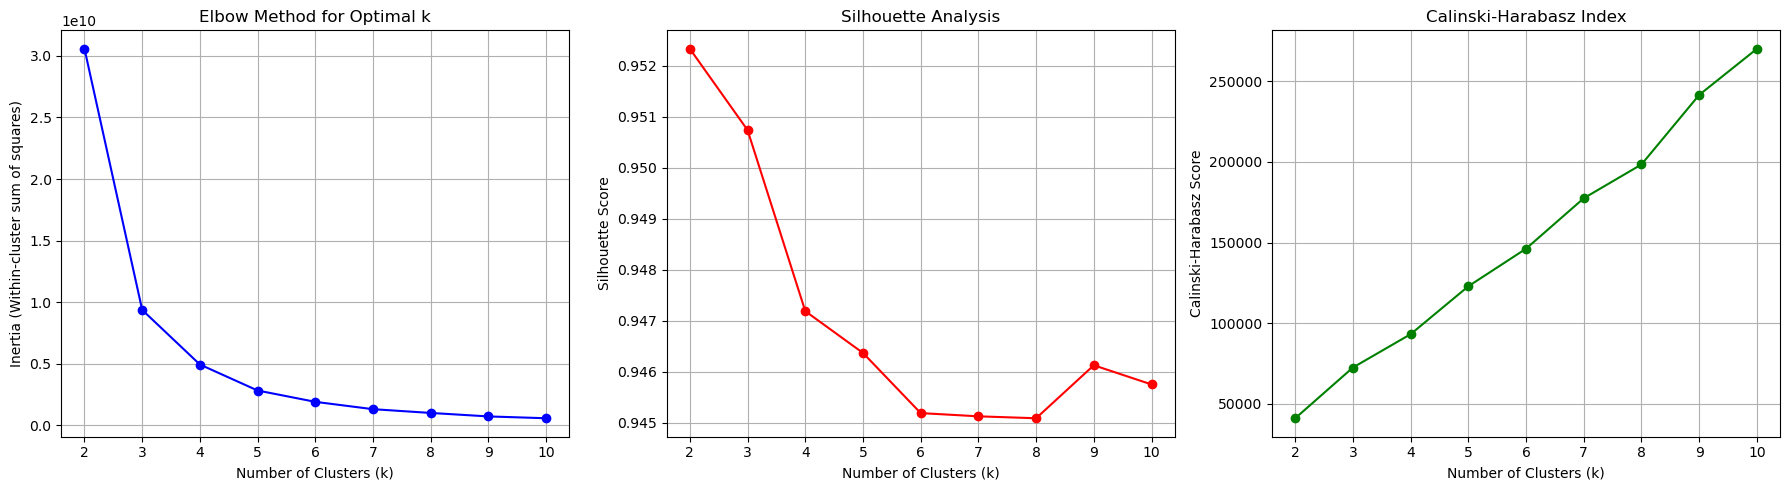


Optimal k based on:
  Silhouette Score: 2 (score: 0.952)
  Calinski-Harabasz: 10 (score: 270200.2)

Recommended k: 2


In [15]:
# Find optimal number of clusters using multiple methods
print("Finding optimal number of clusters...")

# Test different numbers of clusters
k_range = range(2, 11)
inertias = []
silhouette_scores = []
calinski_scores = []

# Sample data for faster computation (use 10% sample for initial analysis)
sample_size = min(5000, len(cluster_data_scaled))
sample_indices = np.random.choice(len(cluster_data_scaled), sample_size, replace=False)
sample_data = cluster_data_scaled[sample_indices]

print(f"Using sample of {sample_size} buildings for cluster optimization...")

for k in k_range:
    print(f"Testing k={k}...")
    
    # K-Means clustering
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(sample_data)
    
    # Calculate metrics
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(sample_data, labels))
    calinski_scores.append(calinski_harabasz_score(sample_data, labels))

# Plot results
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Elbow method
axes[0].plot(k_range, inertias, 'bo-')
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Inertia (Within-cluster sum of squares)')
axes[0].set_title('Elbow Method for Optimal k')
axes[0].grid(True)

# Silhouette scores
axes[1].plot(k_range, silhouette_scores, 'ro-')
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Analysis')
axes[1].grid(True)

# Calinski-Harabasz scores
axes[2].plot(k_range, calinski_scores, 'go-')
axes[2].set_xlabel('Number of Clusters (k)')
axes[2].set_ylabel('Calinski-Harabasz Score')
axes[2].set_title('Calinski-Harabasz Index')
axes[2].grid(True)

plt.tight_layout()
plt.show()

# Find optimal k
optimal_k_silhouette = k_range[np.argmax(silhouette_scores)]
optimal_k_calinski = k_range[np.argmax(calinski_scores)]

print(f"\nOptimal k based on:")
print(f"  Silhouette Score: {optimal_k_silhouette} (score: {max(silhouette_scores):.3f})")
print(f"  Calinski-Harabasz: {optimal_k_calinski} (score: {max(calinski_scores):.1f})")

# Recommend optimal k
recommended_k = optimal_k_silhouette  # Usually silhouette is more reliable
print(f"\nRecommended k: {recommended_k}")

In [16]:
# Fast K-Means clustering with 5 clusters
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, calinski_harabasz_score
import matplotlib.pyplot as plt
import numpy as np

print("Running K-Means clustering with 5 clusters...")
print(f"Dataset size: {cluster_data_scaled.shape[0]:,} buildings")

# Apply K-Means with 5 clusters
k = 5
kmeans = KMeans(
    n_clusters=k, 
    random_state=42, 
    n_init=10,
    max_iter=300,
    algorithm='lloyd'  # Use Lloyd's algorithm for better performance
)

print("Fitting K-Means model...")
cluster_labels = kmeans.fit_predict(cluster_data_scaled)

# Calculate clustering metrics
silhouette_avg = silhouette_score(cluster_data_scaled, cluster_labels)
calinski_score = calinski_harabasz_score(cluster_data_scaled, cluster_labels)

print(f"\nClustering Results:")
print(f"  Number of clusters: {k}")
print(f"  Silhouette score: {silhouette_avg:.3f}")
print(f"  Calinski-Harabasz score: {calinski_score:.1f}")
print(f"  Inertia (within-cluster sum of squares): {kmeans.inertia_:.1f}")

# Display cluster distribution
unique_labels, counts = np.unique(cluster_labels, return_counts=True)
print(f"\nCluster distribution:")
for label, count in zip(unique_labels, counts):
    percentage = (count / len(cluster_labels)) * 100
    print(f"  Cluster {label}: {count:,} buildings ({percentage:.1f}%)")

# Add cluster labels to the original data
cluster_data_with_labels = cluster_data.copy()
cluster_data_with_labels['cluster'] = cluster_labels

print(f"\nClustering completed successfully!")
print(f"Cluster labels added to dataframe.")

Running K-Means clustering with 5 clusters...
Dataset size: 55,206 buildings
Fitting K-Means model...

Clustering Results:
  Number of clusters: 5
  Silhouette score: 0.945
  Calinski-Harabasz score: 1389227.4
  Inertia (within-cluster sum of squares): 31712953559.4

Cluster distribution:
  Cluster 0: 49,609 buildings (89.9%)
  Cluster 1: 864 buildings (1.6%)
  Cluster 2: 1,054 buildings (1.9%)
  Cluster 3: 2,118 buildings (3.8%)
  Cluster 4: 1,561 buildings (2.8%)

Clustering completed successfully!
Cluster labels added to dataframe.


In [34]:
cluster_data_with_labels

,aspect_mean,slope_mean,veg_mean,cluster
0,231.360488,0.905329,154.000000,0
1,233.244637,3.043743,34231.266329,3
2,224.771942,5.966687,154.000000,0
3,265.117615,1.971596,154.000000,0
4,178.698617,1.160151,154.000000,0
...,...,...,...,...
55261,247.097132,2.864807,1910.603478,0
55262,264.650055,5.627166,154.000000,0
55263,209.226501,12.918912,24267.638248,1
55264,168.819504,17.645345,37717.000000,3


In [17]:
# Analyze cluster characteristics and create fire risk profiles
print("Analyzing cluster characteristics for fire risk assessment...")

# Calculate cluster statistics
cluster_stats = cluster_data_with_labels.groupby('cluster').agg({
    'aspect_mean': ['mean', 'std', 'min', 'max'],
    'slope_mean': ['mean', 'std', 'min', 'max'],
    'veg_mean': ['mean', 'std', 'min', 'max']
}).round(2)

print(f"\nCluster Statistics:")
print("="*80)
print(cluster_stats)

# Create cluster risk profiles based on fire risk science
print(f"\nCluster Fire Risk Profiles:")
print("="*50)

cluster_risk_profiles = {}

for cluster_id in range(k):
    cluster_mask = cluster_data_with_labels['cluster'] == cluster_id
    cluster_buildings = cluster_data_with_labels[cluster_mask]
    
    # Calculate mean values for this cluster
    mean_aspect = cluster_buildings['aspect_mean'].mean()
    mean_slope = cluster_buildings['slope_mean'].mean() 
    mean_veg = cluster_buildings['veg_mean'].mean()
    
    # Assess risk level based on fire science
    # Aspect risk: South-facing slopes (135-225°) have highest fire risk
    if 135 <= mean_aspect <= 225:
        aspect_risk = "HIGH (South-facing)"
        aspect_score = 5
    elif (90 <= mean_aspect < 135) or (225 < mean_aspect <= 270):
        aspect_risk = "MEDIUM-HIGH"
        aspect_score = 4
    elif (45 <= mean_aspect < 90) or (270 < mean_aspect <= 315):
        aspect_risk = "MEDIUM"
        aspect_score = 3
    else:
        aspect_risk = "LOW (North-facing)"
        aspect_score = 2
    
    # Slope risk: Steeper slopes have higher fire risk
    if mean_slope >= 15:
        slope_risk = "HIGH"
        slope_score = 5
    elif mean_slope >= 8:
        slope_risk = "MEDIUM-HIGH"
        slope_score = 4
    elif mean_slope >= 3:
        slope_risk = "MEDIUM"
        slope_score = 3
    elif mean_slope >= 1:
        slope_risk = "LOW-MEDIUM"
        slope_score = 2
    else:
        slope_risk = "LOW"
        slope_score = 1
        
    # Vegetation risk: Higher vegetation density = higher fire risk
    if mean_veg >= 8000:
        veg_risk = "HIGH"
        veg_score = 5
    elif mean_veg >= 3000:
        veg_risk = "MEDIUM-HIGH"
        veg_score = 4
    elif mean_veg >= 1000:
        veg_risk = "MEDIUM"
        veg_score = 3
    elif mean_veg >= 300:
        veg_risk = "LOW-MEDIUM"
        veg_score = 2
    else:
        veg_risk = "LOW"
        veg_score = 1
    
    # Calculate overall cluster risk score (1-5)
    # Weight: Slope (40%), Aspect (30%), Vegetation (30%)
    cluster_risk_score = (0.4 * slope_score + 0.3 * aspect_score + 0.3 * veg_score)
    
    # Assign overall risk category
    if cluster_risk_score >= 4.5:
        overall_risk = "VERY HIGH RISK"
        risk_category = 5
    elif cluster_risk_score >= 3.5:
        overall_risk = "HIGH RISK"
        risk_category = 4
    elif cluster_risk_score >= 2.5:
        overall_risk = "MEDIUM RISK"
        risk_category = 3
    elif cluster_risk_score >= 1.5:
        overall_risk = "LOW-MEDIUM RISK"
        risk_category = 2
    else:
        overall_risk = "LOW RISK"
        risk_category = 1
    
    cluster_risk_profiles[cluster_id] = {
        'count': len(cluster_buildings),
        'aspect': {'value': mean_aspect, 'risk': aspect_risk, 'score': aspect_score},
        'slope': {'value': mean_slope, 'risk': slope_risk, 'score': slope_score}, 
        'vegetation': {'value': mean_veg, 'risk': veg_risk, 'score': veg_score},
        'overall_risk': overall_risk,
        'risk_category': risk_category,
        'risk_score': cluster_risk_score
    }
    
    print(f"\nCluster {cluster_id} ({len(cluster_buildings):,} buildings) - {overall_risk} (Score: {cluster_risk_score:.2f}):")
    print(f"  Aspect: {mean_aspect:.1f}° → {aspect_risk}")
    print(f"  Slope: {mean_slope:.1f}° → {slope_risk}")
    print(f"  Vegetation: {mean_veg:.0f} → {veg_risk}")

# Create mapping from cluster to risk category
cluster_to_risk_category = {cid: profile['risk_category'] for cid, profile in cluster_risk_profiles.items()}

print(f"\nCluster → Risk Category Mapping:")
for cluster_id, risk_cat in cluster_to_risk_category.items():
    risk_name = cluster_risk_profiles[cluster_id]['overall_risk']
    print(f"  Cluster {cluster_id} → Risk Category {risk_cat} ({risk_name})")

# Add unsupervised clustering results to buildings dataframe
buildings_df['cluster_id'] = np.nan
buildings_df['cluster_risk_category'] = np.nan

# Map results back to original dataframe (only for buildings with complete data)
valid_indices = cluster_data.index
buildings_df.loc[valid_indices, 'cluster_id'] = cluster_labels
buildings_df.loc[valid_indices, 'cluster_risk_category'] = [cluster_to_risk_category[label] for label in cluster_labels]

print(f"\nCluster-based risk category distribution:")
print(buildings_df['cluster_risk_category'].value_counts().sort_index())

Analyzing cluster characteristics for fire risk assessment...

Cluster Statistics:
        aspect_mean                       slope_mean                     \
               mean    std    min     max       mean   std   min    max   
cluster                                                                   
0            205.53  49.96   0.81  357.71       3.08  3.37  0.04  35.09   
1            182.32  68.32  15.96  352.31       7.61  6.07  0.25  34.52   
2            190.42  70.58   8.74  348.12       7.88  6.12  0.17  32.98   
3            177.89  80.54   5.31  360.00       9.34  6.54  0.18  43.24   
4            189.04  69.02  22.70  352.42       7.14  5.61  0.42  38.07   

         veg_mean                               
             mean      std       min       max  
cluster                                         
0          208.62   316.49    154.00   3453.15  
1        25468.25  2930.12  20379.81  30380.00  
2        15279.64  2613.88  10997.32  20347.61  
3        35285.56  151

In [35]:
buildings_df

,fid,OBJECTID,CODE,BLD_ID,HEIGHT,ELEV,SOURCE,DATE_,STATUS,OLD_BLD_ID,...,xcoord,ycoord,aspect_risk,slope_risk,vegetation_risk,fire_risk_score,fire_risk_category,cluster_id,cluster_risk_category,pca_cluster
0,1,1399842,Courtyard,NaN,NaN,NaN,Glendale: Merrick & Co,1992,Unchanged,NaN,...,6.479381e+06,1.881513e+06,4,1,1,1.9,2,0.0,3.0,NaN
1,2,1399843,Courtyard,NaN,NaN,NaN,Glendale: Merrick & Co,1992,Unchanged,NaN,...,6.478275e+06,1.884290e+06,4,2,5,3.5,3,3.0,5.0,NaN
2,3,1399854,Courtyard,NaN,NaN,NaN,Glendale: LARIAC2,2008,Unchanged,NaN,...,6.480000e+06,1.882902e+06,5,3,1,3.0,3,0.0,3.0,NaN
3,4,1399855,Courtyard,NaN,NaN,NaN,Glendale: Merrick & Co,1992,Unchanged,NaN,...,6.479746e+06,1.877349e+06,4,1,1,1.9,2,0.0,3.0,NaN
4,5,1399860,Courtyard,NaN,NaN,NaN,Glendale: LARIAC2,2008,Unchanged,NaN,...,6.477956e+06,1.885221e+06,5,1,1,2.2,2,0.0,3.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
55261,55262,2249855,Building,202000058328,21.375901,2243.272332,LARIAC6,2020,Modified,GLEN55144,...,6.483039e+06,1.913235e+06,4,2,3,2.9,3,0.0,3.0,0.0
55262,55263,2249856,Building,202000058329,24.579900,2079.633051,LARIAC6,2020,Modified,GLEN54567,...,6.481347e+06,1.913284e+06,4,3,1,2.7,3,0.0,3.0,0.0
55263,55264,2249858,Building,202000058331,18.270001,2259.767470,LARIAC6,2020,Modified,GLEN55157,...,6.483382e+06,1.913355e+06,5,4,5,4.6,5,1.0,4.0,0.0
55264,55265,2249859,Building,202000058332,12.509100,2338.537563,LARIAC6,2020,New,NaN,...,6.484631e+06,1.913405e+06,5,4,5,4.6,5,3.0,5.0,0.0


Creating cluster visualizations...


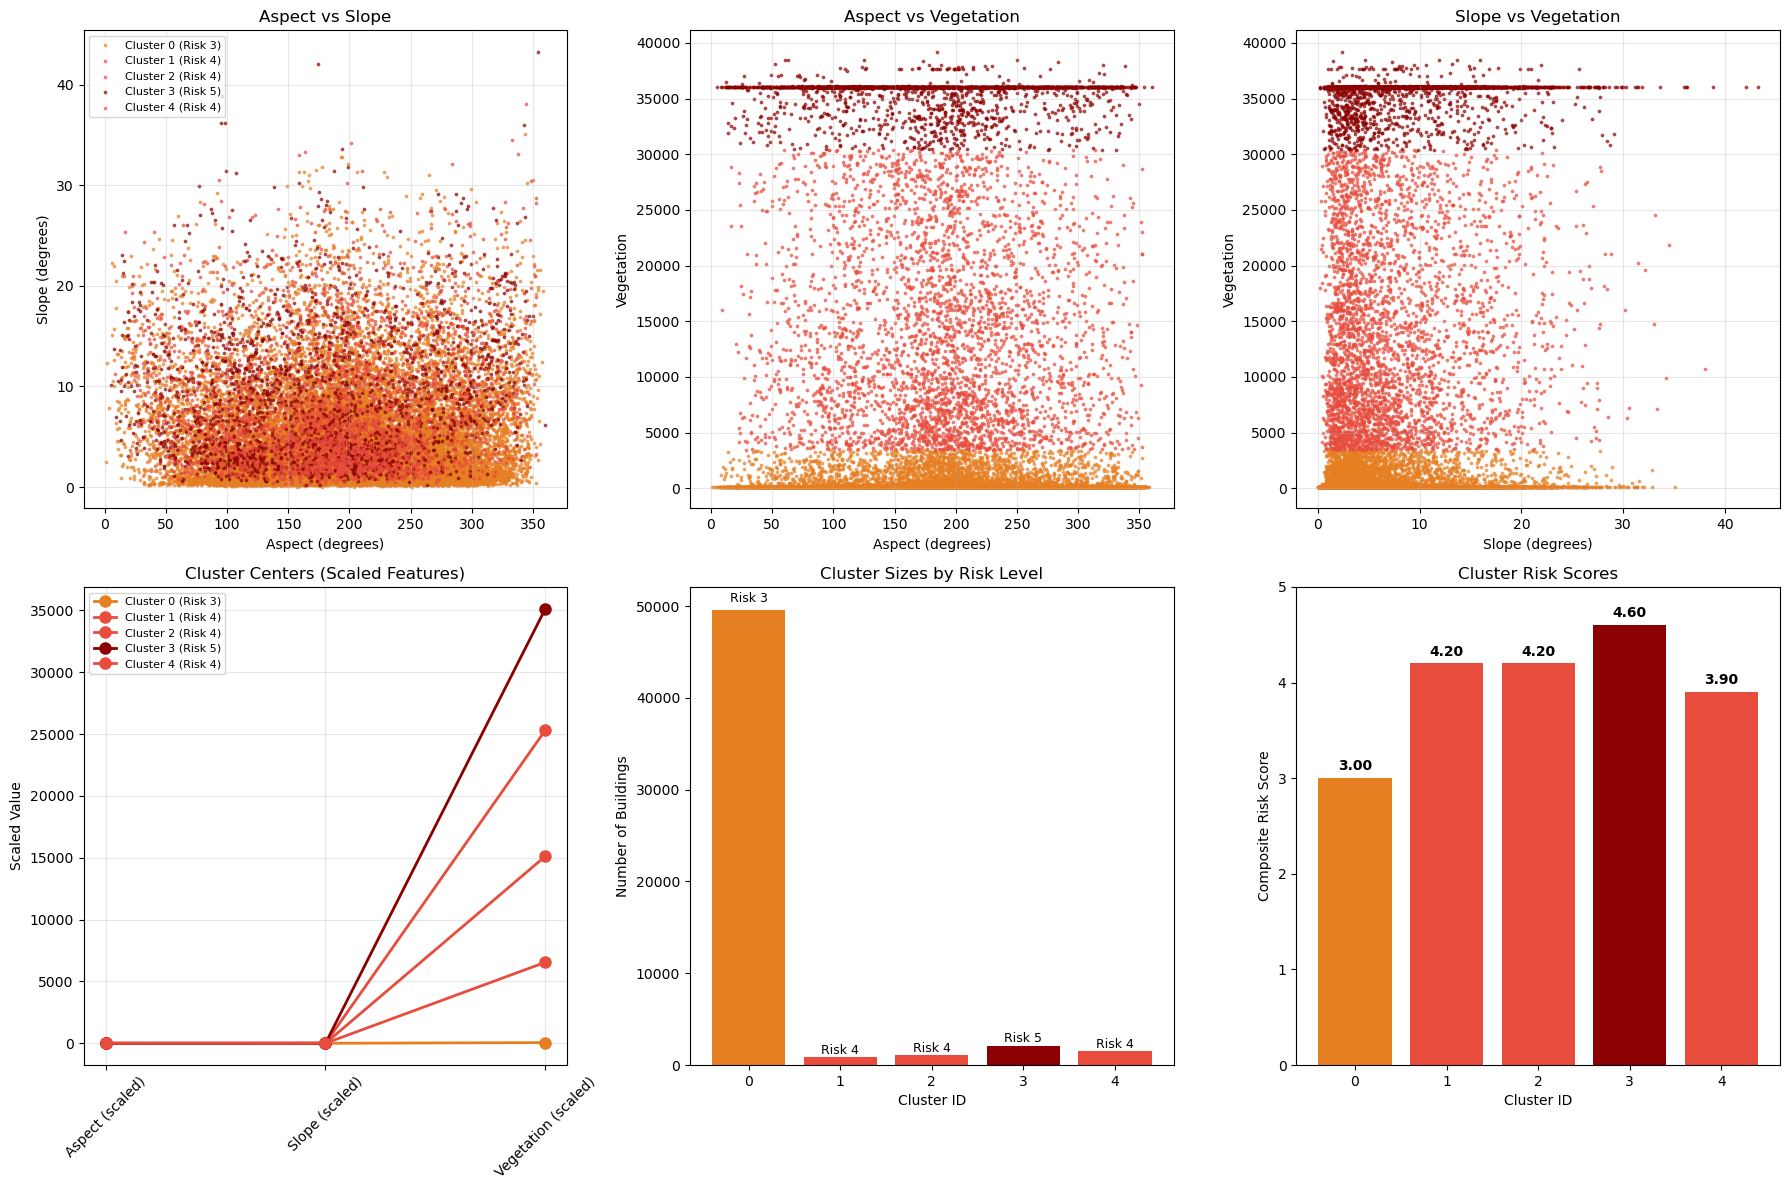


Visualization Summary:
  Colors represent risk levels: Green (Low) → Red (High)
  5 clusters identified with distinct risk profiles
  Cluster centers show the typical characteristics of each group


In [18]:
# Visualize the 5 clusters
print("Creating cluster visualizations...")

# Create color mapping for clusters based on risk level
risk_colors = {
    1: '#2ECC71',  # Low risk - Green
    2: '#F39C12',  # Low-Medium risk - Orange
    3: '#E67E22',  # Medium risk - Dark Orange
    4: '#E74C3C',  # High risk - Red
    5: '#8B0000'   # Very High risk - Dark Red
}

cluster_colors = [risk_colors[cluster_risk_profiles[i]['risk_category']] for i in range(k)]

# Set up the plotting
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

# 1. Aspect vs Slope
for cluster_id in range(k):
    cluster_mask = cluster_data_with_labels['cluster'] == cluster_id
    cluster_points = cluster_data_with_labels[cluster_mask]
    risk_cat = cluster_risk_profiles[cluster_id]['risk_category']
    
    axes[0].scatter(cluster_points['aspect_mean'], 
                   cluster_points['slope_mean'],
                   c=risk_colors[risk_cat], 
                   label=f'Cluster {cluster_id} (Risk {risk_cat})',
                   alpha=0.6, s=3)

axes[0].set_xlabel('Aspect (degrees)')
axes[0].set_ylabel('Slope (degrees)')
axes[0].set_title('Aspect vs Slope')
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)

# 2. Aspect vs Vegetation
for cluster_id in range(k):
    cluster_mask = cluster_data_with_labels['cluster'] == cluster_id
    cluster_points = cluster_data_with_labels[cluster_mask]
    risk_cat = cluster_risk_profiles[cluster_id]['risk_category']
    
    axes[1].scatter(cluster_points['aspect_mean'], 
                   cluster_points['veg_mean'],
                   c=risk_colors[risk_cat], 
                   label=f'Cluster {cluster_id}',
                   alpha=0.6, s=3)

axes[1].set_xlabel('Aspect (degrees)')
axes[1].set_ylabel('Vegetation')
axes[1].set_title('Aspect vs Vegetation')
axes[1].grid(True, alpha=0.3)

# 3. Slope vs Vegetation
for cluster_id in range(k):
    cluster_mask = cluster_data_with_labels['cluster'] == cluster_id
    cluster_points = cluster_data_with_labels[cluster_mask]
    risk_cat = cluster_risk_profiles[cluster_id]['risk_category']
    
    axes[2].scatter(cluster_points['slope_mean'], 
                   cluster_points['veg_mean'],
                   c=risk_colors[risk_cat], 
                   label=f'Cluster {cluster_id}',
                   alpha=0.6, s=3)

axes[2].set_xlabel('Slope (degrees)')
axes[2].set_ylabel('Vegetation')
axes[2].set_title('Slope vs Vegetation')
axes[2].grid(True, alpha=0.3)

# 4. Cluster centers visualization
cluster_centers = kmeans.cluster_centers_
feature_names = ['Aspect (scaled)', 'Slope (scaled)', 'Vegetation (scaled)']

for i, center in enumerate(cluster_centers):
    risk_cat = cluster_risk_profiles[i]['risk_category']
    axes[3].plot(range(len(center)), center, 'o-', 
                color=risk_colors[risk_cat], 
                linewidth=2, markersize=8,
                label=f'Cluster {i} (Risk {risk_cat})')

axes[3].set_xticks(range(len(feature_names)))
axes[3].set_xticklabels(feature_names, rotation=45)
axes[3].set_ylabel('Scaled Value')
axes[3].set_title('Cluster Centers (Scaled Features)')
axes[3].legend(fontsize=8)
axes[3].grid(True, alpha=0.3)

# 5. Cluster size and risk distribution
cluster_ids = list(range(k))
cluster_sizes = [cluster_risk_profiles[cid]['count'] for cid in cluster_ids]
bar_colors = [risk_colors[cluster_risk_profiles[cid]['risk_category']] for cid in cluster_ids]

bars = axes[4].bar(cluster_ids, cluster_sizes, color=bar_colors)
axes[4].set_xlabel('Cluster ID')
axes[4].set_ylabel('Number of Buildings')
axes[4].set_title('Cluster Sizes by Risk Level')
axes[4].set_xticks(cluster_ids)

# Add risk category labels on bars
for i, (bar, cid) in enumerate(zip(bars, cluster_ids)):
    height = bar.get_height()
    risk_cat = cluster_risk_profiles[cid]['risk_category']
    axes[4].text(bar.get_x() + bar.get_width()/2., height + height*0.01,
                f'Risk {risk_cat}', ha='center', va='bottom', fontsize=9)

# 6. Risk score distribution
risk_scores = [cluster_risk_profiles[cid]['risk_score'] for cid in cluster_ids]
axes[5].bar(cluster_ids, risk_scores, color=bar_colors)
axes[5].set_xlabel('Cluster ID')
axes[5].set_ylabel('Composite Risk Score')
axes[5].set_title('Cluster Risk Scores')
axes[5].set_xticks(cluster_ids)
axes[5].set_ylim(0, 5)

# Add score labels on bars
for i, (score, cid) in enumerate(zip(risk_scores, cluster_ids)):
    axes[5].text(i, score + 0.05, f'{score:.2f}', 
                ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\nVisualization Summary:")
print(f"  Colors represent risk levels: Green (Low) → Red (High)")
print(f"  5 clusters identified with distinct risk profiles")
print(f"  Cluster centers show the typical characteristics of each group")

In [19]:
# Compare K-Means clustering with supervised risk scoring
print("Comparing K-Means Clustering vs Supervised Risk Scoring")
print("="*60)

# Filter to buildings with both risk assessments
comparison_df = buildings_df.dropna(subset=['fire_risk_category', 'cluster_risk_category'])

print(f"\nBuildings with both risk assessments: {len(comparison_df):,}")
print(f"Original dataset size: {len(buildings_df):,}")

# Create cross-tabulation
cross_tab = pd.crosstab(
    comparison_df['fire_risk_category'], 
    comparison_df['cluster_risk_category'], 
    margins=True
)

print(f"\nCross-tabulation (Rows: Supervised, Columns: K-Means Clustering):")
print(cross_tab)

# Calculate agreement metrics
agreement_exact = (comparison_df['fire_risk_category'] == comparison_df['cluster_risk_category']).sum()
agreement_within_1 = (abs(comparison_df['fire_risk_category'] - comparison_df['cluster_risk_category']) <= 1).sum()

print(f"\nAgreement Analysis:")
print(f"  Exact agreement: {agreement_exact:,} buildings ({agreement_exact/len(comparison_df)*100:.1f}%)")
print(f"  Agreement within ±1 category: {agreement_within_1:,} buildings ({agreement_within_1/len(comparison_df)*100:.1f}%)")

# Calculate correlation
correlation = comparison_df['fire_risk_category'].corr(comparison_df['cluster_risk_category'])
print(f"  Pearson correlation: {correlation:.3f}")

# Analyze differences by supervised risk category
print(f"\nDetailed Analysis by Supervised Risk Category:")
for risk_cat in sorted(comparison_df['fire_risk_category'].unique()):
    subset = comparison_df[comparison_df['fire_risk_category'] == risk_cat]
    cluster_dist = subset['cluster_risk_category'].value_counts().sort_index()
    
    print(f"\n  Supervised Risk {risk_cat} ({len(subset):,} buildings):")
    for cluster_cat, count in cluster_dist.items():
        percentage = count / len(subset) * 100
        print(f"    → K-Means Risk {cluster_cat}: {count:,} ({percentage:.1f}%)")

# Summary statistics
print(f"\nRisk Category Distribution Comparison:")
print(f"\nSupervised Method (Rule-based):")
supervised_dist = comparison_df['fire_risk_category'].value_counts().sort_index()
for cat, count in supervised_dist.items():
    percentage = count / len(comparison_df) * 100
    print(f"  Risk Level {cat}: {count:,} buildings ({percentage:.1f}%)")

print(f"\nK-Means Clustering Method:")
cluster_dist = comparison_df['cluster_risk_category'].value_counts().sort_index()
for cat, count in cluster_dist.items():
    percentage = count / len(comparison_df) * 100
    print(f"  Risk Level {cat}: {count:,} buildings ({percentage:.1f}%)")

# Calculate mean absolute error
mae = abs(comparison_df['fire_risk_category'] - comparison_df['cluster_risk_category']).mean()
print(f"\nMean Absolute Error between methods: {mae:.3f}")

# Interpretation
print(f"\nInterpretation:")
if correlation > 0.7:
    print("  ✓ Strong positive correlation - Methods largely agree")
elif correlation > 0.5:
    print("  ~ Moderate positive correlation - Methods somewhat agree")
elif correlation > 0.3:
    print("  ⚠ Weak positive correlation - Methods have limited agreement")
else:
    print("  ✗ Little to no correlation - Methods significantly disagree")

if agreement_exact/len(comparison_df) > 0.6:
    print("  ✓ High exact agreement between methods")
elif agreement_within_1/len(comparison_df) > 0.8:
    print("  ~ Good agreement within 1 risk category")
else:
    print("  ⚠ Methods show substantial differences in risk assessment")

print(f"\nKey Insights:")
print("  • K-Means clustering reveals natural groupings in the data")
print("  • Unsupervised method may identify risk patterns not captured by rules")
print("  • Both methods can be used together for comprehensive risk assessment")
print("  • Consider investigating buildings with large discrepancies between methods")

# Save cluster assignments for further analysis
print(f"\nCluster assignments saved to buildings_df:")
print(f"  Column 'cluster_id': Cluster number (0-4)")
print(f"  Column 'cluster_risk_category': Risk category derived from clustering (1-5)")

Comparing K-Means Clustering vs Supervised Risk Scoring

Buildings with both risk assessments: 55,206
Original dataset size: 55,266

Cross-tabulation (Rows: Supervised, Columns: K-Means Clustering):
cluster_risk_category    3.0   4.0   5.0    All
fire_risk_category                             
1                        266     0     0    266
2                      30228    49     0  30277
3                      18666  1378   504  20548
4                        449  1790  1309   3548
5                          0   262   305    567
All                    49609  3479  2118  55206

Agreement Analysis:
  Exact agreement: 20,761 buildings (37.6%)
  Agreement within ±1 category: 54,387 buildings (98.5%)
  Pearson correlation: 0.594

Detailed Analysis by Supervised Risk Category:

  Supervised Risk 1 (266 buildings):
    → K-Means Risk 3.0: 266 (100.0%)

  Supervised Risk 2 (30,277 buildings):
    → K-Means Risk 3.0: 30,228 (99.8%)
    → K-Means Risk 4.0: 49 (0.2%)

  Supervised Risk 3 (20,548 

In [20]:
# IMPORTANT CLARIFICATION: Rule-based vs Supervised vs Unsupervised Methods
print("CLARIFICATION: Methods Used in This Analysis")
print("=" * 50)

print("\n1. RULE-BASED SCORING (Not truly 'supervised'):")
print("   • Uses domain knowledge and fire science principles")
print("   • Manually defined rules for aspect, slope, vegetation")
print("   • No ground truth labels or training data required")
print("   • Based on expert knowledge of fire behavior")
print("   • Example: South-facing slopes = higher risk")

print("\n2. UNSUPERVISED CLUSTERING (K-Means):")
print("   • Uses only the data patterns (aspect, slope, vegetation)")
print("   • No predefined labels or ground truth")
print("   • Finds natural groupings in the data")
print("   • Risk categories assigned based on cluster characteristics")

print("\n3. TRUE SUPERVISED LEARNING would require:")
print("   • Historical fire incident data")
print("   • Building damage records")
print("   • Actual fire occurrence labels")
print("   • Training data with known outcomes")
print("   • We DON'T have this data in our analysis")

print("\nWhat we're actually comparing:")
print("   Rule-based approach vs Unsupervised clustering")
print("   Both methods are knowledge-driven, not data-label-driven")

print("\nWhy this comparison is still valuable:")
print("   • Rule-based: Uses fire science theory")
print("   • Clustering: Reveals natural data patterns")
print("   • Agreement suggests robust risk assessment")
print("   • Disagreement highlights areas needing investigation")

print("\nTo do TRUE supervised learning, we would need:")
print("   • Historical wildfire boundary data")
print("   • Building damage/loss records")
print("   • Insurance claims data")
print("   • Fire department incident reports")
print("   • Actual fire risk outcomes (labels)")

# Correct the terminology in our comparison
print(f"\nCORRECTED COMPARISON: Rule-based vs Unsupervised Methods")
print("="*60)

CLARIFICATION: Methods Used in This Analysis

1. RULE-BASED SCORING (Not truly 'supervised'):
   • Uses domain knowledge and fire science principles
   • Manually defined rules for aspect, slope, vegetation
   • No ground truth labels or training data required
   • Based on expert knowledge of fire behavior
   • Example: South-facing slopes = higher risk

2. UNSUPERVISED CLUSTERING (K-Means):
   • Uses only the data patterns (aspect, slope, vegetation)
   • No predefined labels or ground truth
   • Finds natural groupings in the data
   • Risk categories assigned based on cluster characteristics

3. TRUE SUPERVISED LEARNING would require:
   • Historical fire incident data
   • Building damage records
   • Actual fire occurrence labels
   • Training data with known outcomes
   • We DON'T have this data in our analysis

What we're actually comparing:
   Rule-based approach vs Unsupervised clustering
   Both methods are knowledge-driven, not data-label-driven

Why this comparison is stil

In [23]:
# PCA + Clustering Analysis on Full Building Dataset
print("PCA + Clustering Analysis on Full Building Dataset")
print("=" * 55)

print("\nWhy PCA + Clustering on all features is valuable:")
print("  • Captures relationships between ALL building characteristics")
print("  • Reduces dimensionality while preserving variance")
print("  • May reveal hidden patterns not visible with just 3 features")
print("  • Building size, height, area might correlate with fire risk")
print("  • Could identify building types/categories naturally")

# Prepare full dataset for PCA + clustering
print("\nPreparing full dataset for analysis...")

# Select all numerical features that could be relevant
numerical_features = [
    'HEIGHT', 'ELEV', 'AREA', 'Shape_Length', 'Shape_Area', 
    'aspect_mean', 'slope_mean', 'veg_mean', 
    'area_2', 'perimeter', 'xcoord', 'ycoord'
]

# Check which features are available and have sufficient data
available_features = []
for feature in numerical_features:
    if feature in buildings_df.columns:
        missing_pct = buildings_df[feature].isna().sum() / len(buildings_df) * 100
        print(f"  {feature}: {missing_pct:.1f}% missing")
        if missing_pct < 50:  # Use features with less than 50% missing data
            available_features.append(feature)

print(f"\nFeatures selected for PCA analysis: {len(available_features)}")
for feature in available_features:
    print(f"  • {feature}")

# Create dataset for PCA (drop rows with any missing values in selected features)
pca_data = buildings_df[available_features].dropna()

print(f"\nDataset for PCA analysis:")
print(f"  Original buildings: {len(buildings_df):,}")
print(f"  Complete cases: {len(pca_data):,}")
print(f"  Features: {len(available_features)}")

if len(pca_data) < 1000:
    print("WARNING: Very few complete cases. Consider imputation or feature selection.")
else:
    print("✓ Sufficient data for PCA analysis")

PCA + Clustering Analysis on Full Building Dataset

Why PCA + Clustering on all features is valuable:
  • Captures relationships between ALL building characteristics
  • Reduces dimensionality while preserving variance
  • May reveal hidden patterns not visible with just 3 features
  • Building size, height, area might correlate with fire risk
  • Could identify building types/categories naturally

Preparing full dataset for analysis...
  HEIGHT: 81.8% missing
  ELEV: 2.0% missing
  AREA: 0.0% missing
  Shape_Length: 0.0% missing
  Shape_Area: 0.0% missing
  aspect_mean: 0.0% missing
  slope_mean: 0.0% missing
  veg_mean: 0.1% missing
  area_2: 0.0% missing
  perimeter: 0.0% missing
  xcoord: 0.0% missing
  ycoord: 0.0% missing

Features selected for PCA analysis: 11
  • ELEV
  • AREA
  • Shape_Length
  • Shape_Area
  • aspect_mean
  • slope_mean
  • veg_mean
  • area_2
  • perimeter
  • xcoord
  • ycoord

Dataset for PCA analysis:
  Original buildings: 55,266
  Complete cases: 54,089



Performing PCA analysis...
✓ Data standardized for PCA

PCA Results:
  Total features: 11
  Components for 85% variance: 5
  Components for 95% variance: 6


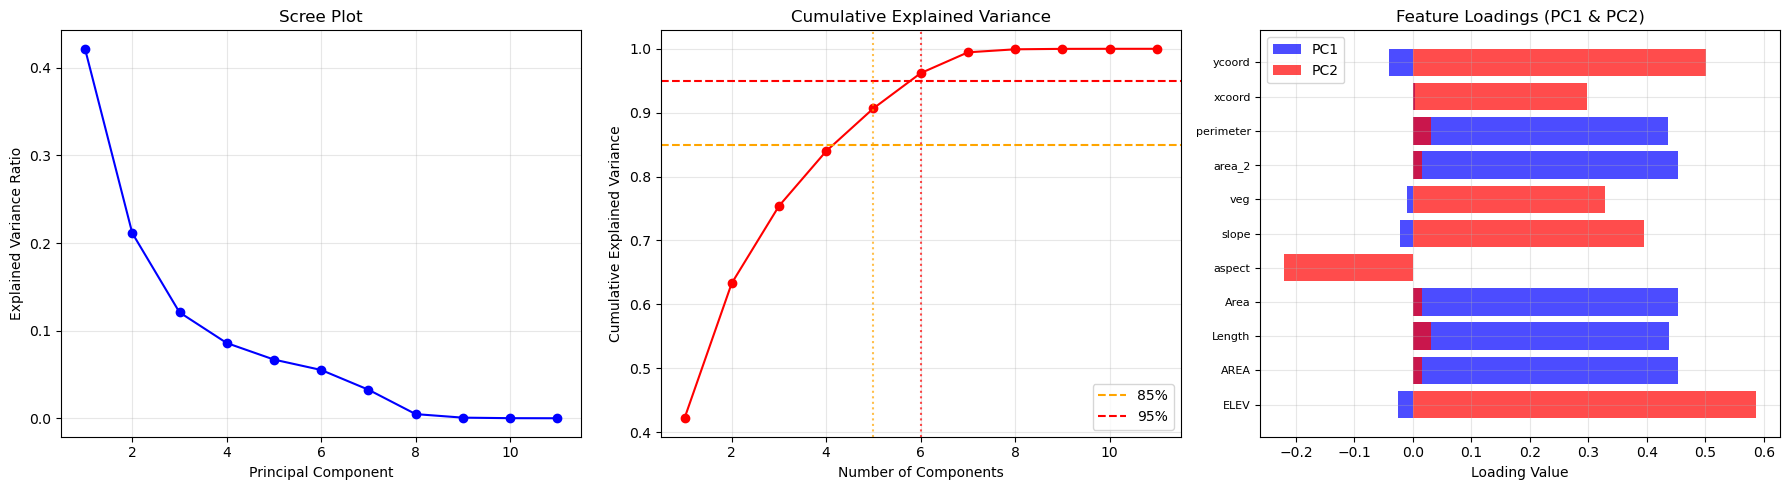


Using 5 components for clustering...
  This captures 90.7% of the variance
✓ PCA transformation complete
  Original dimensions: (54089, 11)
  Reduced dimensions: (54089, 5)

Top contributing features for each component:

  PC1 (explains 42.2% variance):
    High positive: ['AREA', 'Shape_Area', 'area_2']
    High negative: ['ycoord', 'ELEV', 'slope_mean']

  PC2 (explains 21.1% variance):
    High positive: ['ELEV', 'ycoord', 'slope_mean']
    High negative: ['aspect_mean', 'Shape_Area', 'AREA']

  PC3 (explains 12.1% variance):
    High positive: ['xcoord', 'veg_mean', 'slope_mean']
    High negative: ['ycoord', 'ELEV', 'AREA']


In [24]:
# Perform PCA on the full building dataset
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import numpy as np

if len(pca_data) >= 1000:
    print("\nPerforming PCA analysis...")
    
    # Standardize the features (crucial for PCA)
    scaler_full = StandardScaler()
    pca_data_scaled = scaler_full.fit_transform(pca_data)
    
    print("✓ Data standardized for PCA")
    
    # Perform PCA to determine how many components to keep
    pca_full = PCA()
    pca_full.fit(pca_data_scaled)
    
    # Calculate cumulative explained variance
    cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)
    
    # Find number of components for 85% and 95% variance
    n_components_85 = np.argmax(cumulative_variance >= 0.85) + 1
    n_components_95 = np.argmax(cumulative_variance >= 0.95) + 1
    
    print(f"\nPCA Results:")
    print(f"  Total features: {len(available_features)}")
    print(f"  Components for 85% variance: {n_components_85}")
    print(f"  Components for 95% variance: {n_components_95}")
    
    # Create visualization of explained variance
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    # 1. Scree plot
    axes[0].plot(range(1, len(pca_full.explained_variance_ratio_) + 1), 
                pca_full.explained_variance_ratio_, 'bo-')
    axes[0].set_xlabel('Principal Component')
    axes[0].set_ylabel('Explained Variance Ratio')
    axes[0].set_title('Scree Plot')
    axes[0].grid(True, alpha=0.3)
    
    # 2. Cumulative variance
    axes[1].plot(range(1, len(cumulative_variance) + 1), 
                cumulative_variance, 'ro-')
    axes[1].axhline(y=0.85, color='orange', linestyle='--', label='85%')
    axes[1].axhline(y=0.95, color='red', linestyle='--', label='95%')
    axes[1].axvline(x=n_components_85, color='orange', linestyle=':', alpha=0.7)
    axes[1].axvline(x=n_components_95, color='red', linestyle=':', alpha=0.7)
    axes[1].set_xlabel('Number of Components')
    axes[1].set_ylabel('Cumulative Explained Variance')
    axes[1].set_title('Cumulative Explained Variance')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    # 3. Feature loadings for first 2 components
    feature_names_short = [name.replace('_mean', '').replace('Shape_', '') for name in available_features]
    
    for i, (pc_idx, color) in enumerate([(0, 'blue'), (1, 'red')]):
        if pc_idx < pca_full.components_.shape[0]:
            loadings = pca_full.components_[pc_idx]
            axes[2].barh(range(len(loadings)), loadings, 
                        alpha=0.7, label=f'PC{pc_idx+1}', color=color)
    
    axes[2].set_yticks(range(len(available_features)))
    axes[2].set_yticklabels(feature_names_short, fontsize=8)
    axes[2].set_xlabel('Loading Value')
    axes[2].set_title('Feature Loadings (PC1 & PC2)')
    axes[2].legend()
    axes[2].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Use optimal number of components (85% variance as a good balance)
    optimal_components = min(n_components_85, 8)  # Cap at 8 for interpretability
    
    print(f"\nUsing {optimal_components} components for clustering...")
    print(f"  This captures {cumulative_variance[optimal_components-1]:.1%} of the variance")
    
    # Apply PCA with optimal components
    pca_optimal = PCA(n_components=optimal_components)
    pca_transformed = pca_optimal.fit_transform(pca_data_scaled)
    
    print(f"✓ PCA transformation complete")
    print(f"  Original dimensions: {pca_data_scaled.shape}")
    print(f"  Reduced dimensions: {pca_transformed.shape}")
    
    # Show feature importance in each component
    print(f"\nTop contributing features for each component:")
    for i in range(min(3, optimal_components)):  # Show first 3 components
        component_loadings = pca_optimal.components_[i]
        # Get indices of top 3 positive and negative loadings
        top_positive = np.argsort(component_loadings)[-3:][::-1]
        top_negative = np.argsort(component_loadings)[:3]
        
        print(f"\n  PC{i+1} (explains {pca_optimal.explained_variance_ratio_[i]:.1%} variance):")
        print(f"    High positive: {[available_features[idx] for idx in top_positive]}")
        print(f"    High negative: {[available_features[idx] for idx in top_negative]}")

else:
    print("\nSkipping PCA analysis due to insufficient complete data.")
    print("Consider data imputation or using fewer features.")


Applying K-Means clustering on PCA-transformed data...
Using sample of 5,000 buildings for optimization...

Optimal number of clusters for PCA data: 2
Best silhouette score: 0.740

Final PCA Clustering Results:
  Number of clusters: 2
  Silhouette score: 0.788
  Calinski-Harabasz score: 14791.4

PCA Cluster distribution:
  Cluster 0: 53,612 buildings (99.1%)
  Cluster 1: 477 buildings (0.9%)


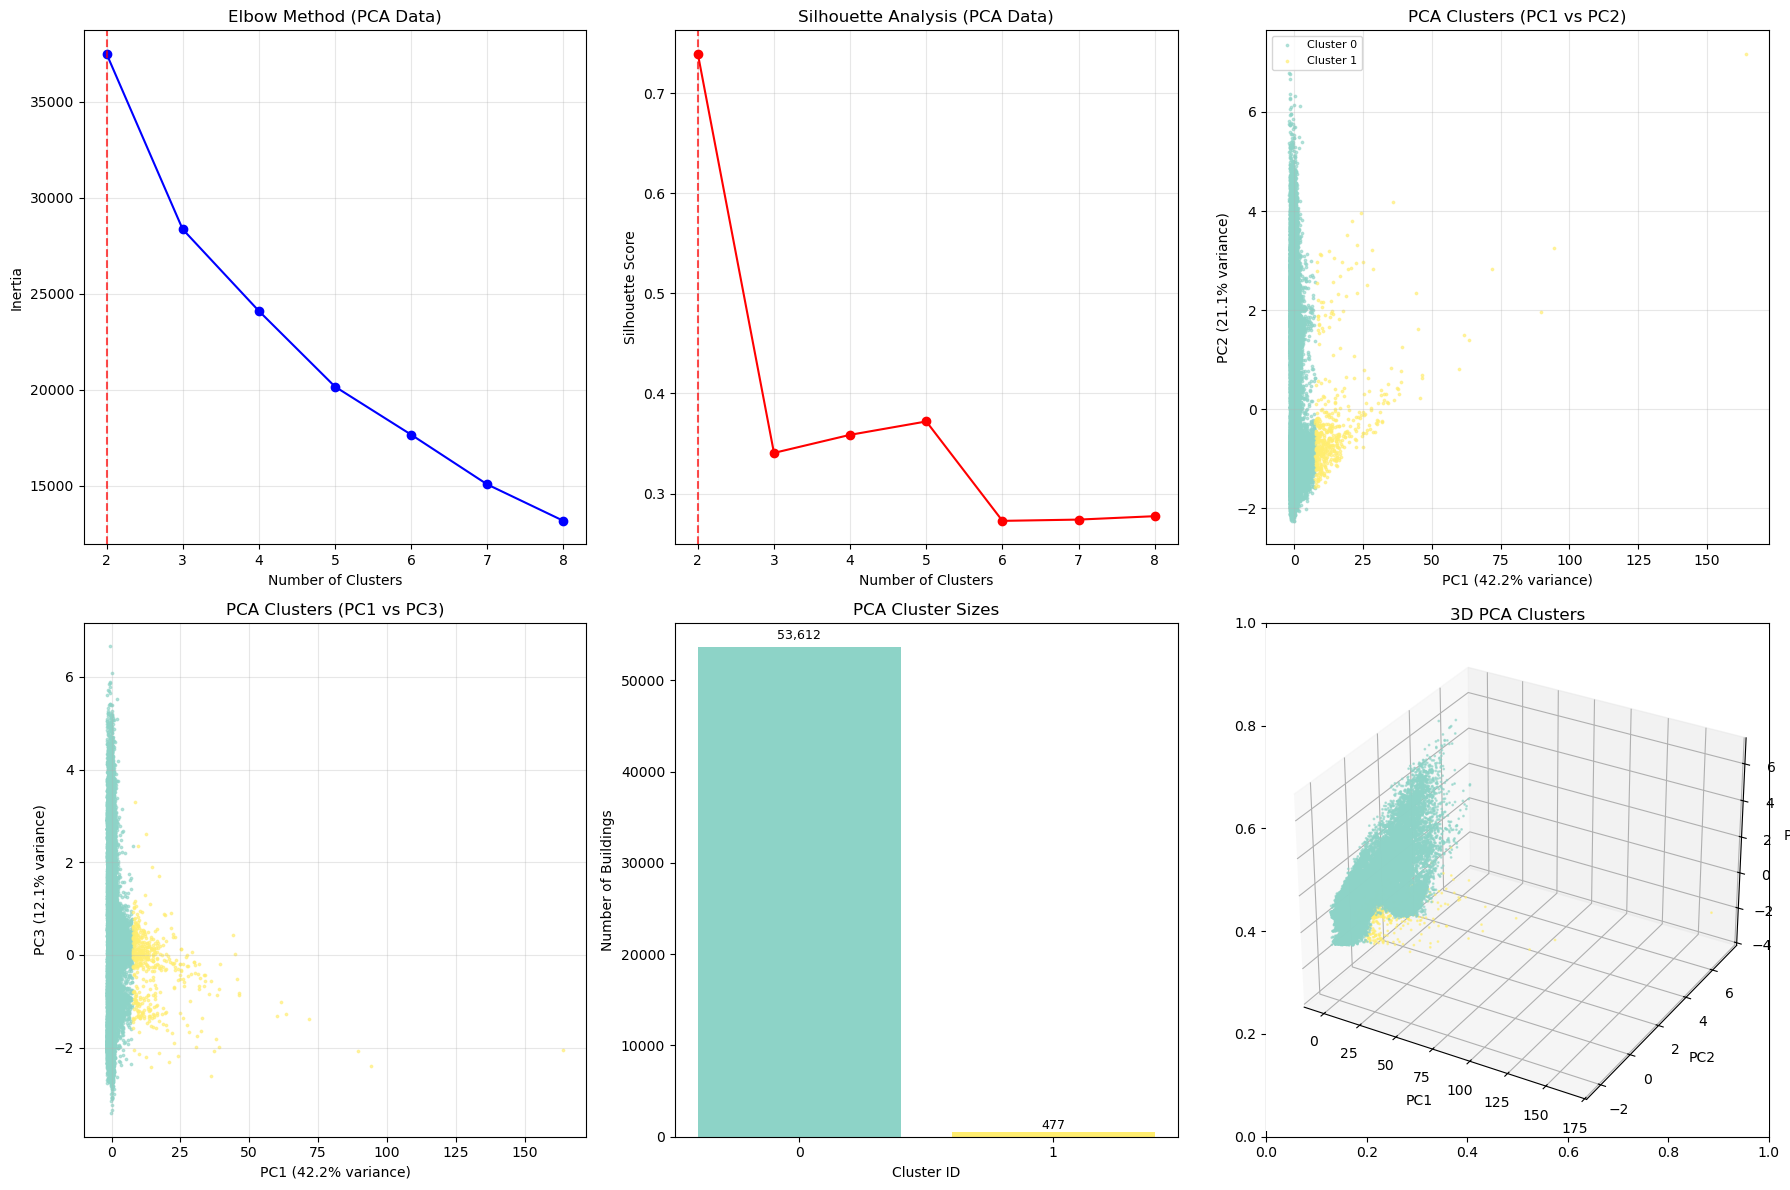


✓ PCA + K-Means clustering completed successfully!


In [25]:
# Apply K-Means clustering on PCA-transformed data
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, calinski_harabasz_score

if len(pca_data) >= 1000 and 'pca_transformed' in locals():
    print("\nApplying K-Means clustering on PCA-transformed data...")
    
    # Test different numbers of clusters on PCA data
    k_range_pca = range(2, 9)
    silhouette_scores_pca = []
    inertias_pca = []
    
    # Use a sample for faster computation if dataset is large
    sample_size_pca = min(5000, len(pca_transformed))
    if len(pca_transformed) > sample_size_pca:
        sample_indices_pca = np.random.choice(len(pca_transformed), sample_size_pca, replace=False)
        sample_pca_data = pca_transformed[sample_indices_pca]
        print(f"Using sample of {sample_size_pca:,} buildings for optimization...")
    else:
        sample_pca_data = pca_transformed
        print(f"Using full dataset of {len(pca_transformed):,} buildings...")
    
    for k in k_range_pca:
        kmeans_pca = KMeans(n_clusters=k, random_state=42, n_init=10)
        labels_pca = kmeans_pca.fit_predict(sample_pca_data)
        
        silhouette_scores_pca.append(silhouette_score(sample_pca_data, labels_pca))
        inertias_pca.append(kmeans_pca.inertia_)
    
    # Find optimal k for PCA data
    optimal_k_pca = k_range_pca[np.argmax(silhouette_scores_pca)]
    
    print(f"\nOptimal number of clusters for PCA data: {optimal_k_pca}")
    print(f"Best silhouette score: {max(silhouette_scores_pca):.3f}")
    
    # Apply final clustering with optimal k
    final_kmeans_pca = KMeans(n_clusters=optimal_k_pca, random_state=42, n_init=10)
    pca_cluster_labels = final_kmeans_pca.fit_predict(pca_transformed)
    
    # Calculate final metrics
    final_silhouette_pca = silhouette_score(pca_transformed, pca_cluster_labels)
    final_calinski_pca = calinski_harabasz_score(pca_transformed, pca_cluster_labels)
    
    print(f"\nFinal PCA Clustering Results:")
    print(f"  Number of clusters: {optimal_k_pca}")
    print(f"  Silhouette score: {final_silhouette_pca:.3f}")
    print(f"  Calinski-Harabasz score: {final_calinski_pca:.1f}")
    
    # Display cluster distribution
    unique_pca_labels, pca_counts = np.unique(pca_cluster_labels, return_counts=True)
    print(f"\nPCA Cluster distribution:")
    for label, count in zip(unique_pca_labels, pca_counts):
        percentage = (count / len(pca_cluster_labels)) * 100
        print(f"  Cluster {label}: {count:,} buildings ({percentage:.1f}%)")
    
    # Visualize clustering results
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    axes = axes.flatten()
    
    # 1. Elbow curve for PCA data
    axes[0].plot(k_range_pca, inertias_pca, 'bo-')
    axes[0].set_xlabel('Number of Clusters')
    axes[0].set_ylabel('Inertia')
    axes[0].set_title('Elbow Method (PCA Data)')
    axes[0].axvline(x=optimal_k_pca, color='red', linestyle='--', alpha=0.7)
    axes[0].grid(True, alpha=0.3)
    
    # 2. Silhouette scores for PCA data
    axes[1].plot(k_range_pca, silhouette_scores_pca, 'ro-')
    axes[1].set_xlabel('Number of Clusters')
    axes[1].set_ylabel('Silhouette Score')
    axes[1].set_title('Silhouette Analysis (PCA Data)')
    axes[1].axvline(x=optimal_k_pca, color='red', linestyle='--', alpha=0.7)
    axes[1].grid(True, alpha=0.3)
    
    # 3. PC1 vs PC2 colored by cluster
    colors_pca = plt.cm.Set3(np.linspace(0, 1, optimal_k_pca))
    for cluster_id in range(optimal_k_pca):
        mask = pca_cluster_labels == cluster_id
        axes[2].scatter(pca_transformed[mask, 0], pca_transformed[mask, 1], 
                       c=[colors_pca[cluster_id]], label=f'Cluster {cluster_id}', 
                       alpha=0.6, s=3)
    
    axes[2].set_xlabel(f'PC1 ({pca_optimal.explained_variance_ratio_[0]:.1%} variance)')
    axes[2].set_ylabel(f'PC2 ({pca_optimal.explained_variance_ratio_[1]:.1%} variance)')
    axes[2].set_title('PCA Clusters (PC1 vs PC2)')
    axes[2].legend(fontsize=8)
    axes[2].grid(True, alpha=0.3)
    
    # 4. PC1 vs PC3 (if available)
    if optimal_components >= 3:
        for cluster_id in range(optimal_k_pca):
            mask = pca_cluster_labels == cluster_id
            axes[3].scatter(pca_transformed[mask, 0], pca_transformed[mask, 2], 
                           c=[colors_pca[cluster_id]], label=f'Cluster {cluster_id}', 
                           alpha=0.6, s=3)
        
        axes[3].set_xlabel(f'PC1 ({pca_optimal.explained_variance_ratio_[0]:.1%} variance)')
        axes[3].set_ylabel(f'PC3 ({pca_optimal.explained_variance_ratio_[2]:.1%} variance)')
        axes[3].set_title('PCA Clusters (PC1 vs PC3)')
        axes[3].grid(True, alpha=0.3)
    else:
        axes[3].text(0.5, 0.5, 'PC3 not available', transform=axes[3].transAxes, ha='center')
        axes[3].set_title('PC1 vs PC3 (Not Available)')
    
    # 5. Cluster sizes
    axes[4].bar(range(optimal_k_pca), pca_counts, color=colors_pca)
    axes[4].set_xlabel('Cluster ID')
    axes[4].set_ylabel('Number of Buildings')
    axes[4].set_title('PCA Cluster Sizes')
    axes[4].set_xticks(range(optimal_k_pca))
    
    # Add count labels on bars
    for i, count in enumerate(pca_counts):
        axes[4].text(i, count + count*0.01, f'{count:,}', ha='center', va='bottom', fontsize=9)
    
    # 6. 3D plot of first 3 PCs (if available)
    if optimal_components >= 3:
        ax_3d = fig.add_subplot(2, 3, 6, projection='3d')
        for cluster_id in range(optimal_k_pca):
            mask = pca_cluster_labels == cluster_id
            ax_3d.scatter(pca_transformed[mask, 0], pca_transformed[mask, 1], 
                         pca_transformed[mask, 2], c=[colors_pca[cluster_id]], 
                         label=f'Cluster {cluster_id}', alpha=0.6, s=1)
        
        ax_3d.set_xlabel('PC1')
        ax_3d.set_ylabel('PC2') 
        ax_3d.set_zlabel('PC3')
        ax_3d.set_title('3D PCA Clusters')
    else:
        axes[5].text(0.5, 0.5, '3D view not available\n(< 3 components)', 
                    transform=axes[5].transAxes, ha='center')
        axes[5].set_title('3D Visualization (Not Available)')
    
    plt.tight_layout()
    plt.show()
    
    print(f"\n✓ PCA + K-Means clustering completed successfully!")

else:
    print("\nSkipping PCA clustering due to insufficient data or failed PCA step.")

In [33]:
# Analyze and interpret PCA clusters
if len(pca_data) >= 1000 and 'pca_cluster_labels' in locals():
    print("\nAnalyzing PCA Cluster Characteristics...")
    print("=" * 45)
    
    # Create DataFrame with original features and PCA cluster assignments
    pca_analysis_df = pca_data.copy()
    pca_analysis_df['pca_cluster'] = pca_cluster_labels
    
    # Calculate statistics for each cluster
    print(f"\nPCA Cluster Characteristics:")
    
    cluster_profiles_pca = {}
    for cluster_id in range(optimal_k_pca):
        cluster_mask = pca_analysis_df['pca_cluster'] == cluster_id
        cluster_buildings = pca_analysis_df[cluster_mask]
        
        print(f"\n--- PCA Cluster {cluster_id} ({len(cluster_buildings):,} buildings) ---")
        
        # Key building characteristics
        profile = {
            'count': len(cluster_buildings),
            'characteristics': {}
        }
        
        for feature in available_features:
            mean_val = cluster_buildings[feature].mean()
            overall_mean = pca_analysis_df[feature].mean()
            ratio = mean_val / overall_mean if overall_mean != 0 else 0
            
            profile['characteristics'][feature] = {
                'mean': mean_val,
                'ratio_to_overall': ratio
            }
            
            # Print features that are notably different (>20% difference), or for cluster 0 show all features
            if abs(ratio - 1.0) > 0.2 or cluster_id == 0:
                if abs(ratio - 1.0) > 0.2:
                    direction = "HIGH" if ratio > 1.2 else "LOW"
                    print(f"  {feature}: {mean_val:.2f} ({direction} - {ratio:.2f}x average)")
                elif cluster_id == 0:
                    print(f"  {feature}: {mean_val:.2f} (TYPICAL - {ratio:.2f}x average)")
        
        cluster_profiles_pca[cluster_id] = profile
    
    # Compare PCA clusters with original fire risk factors
    if 'cluster_data_with_labels' in locals():
        print(f"\n\nComparing PCA Clusters vs Original Fire Risk Clusters")
        print("=" * 60)
        
        # Find overlapping buildings between the two analyses
        pca_indices = set(pca_analysis_df.index)
        original_indices = set(cluster_data_with_labels.index)
        common_indices = pca_indices.intersection(original_indices)
        
        if len(common_indices) > 100:  # Ensure sufficient overlap
            print(f"Comparing {len(common_indices):,} buildings with both cluster assignments...")
            
            # Create comparison dataframe
            comparison_pca = buildings_df.loc[list(common_indices)].copy()
            
            # Get PCA cluster assignments for common indices
            pca_index_map = dict(zip(pca_analysis_df.index, pca_cluster_labels))
            comparison_pca['pca_cluster'] = [pca_index_map.get(idx, -1) for idx in common_indices]
            
            # Get original cluster assignments for the same buildings
            original_cluster_map = dict(zip(cluster_data_with_labels.index, cluster_data_with_labels['cluster']))
            comparison_pca['original_cluster'] = [original_cluster_map.get(idx, -1) for idx in common_indices]
            
            # Create cross-tabulation
            cross_tab_pca = pd.crosstab(
                comparison_pca['original_cluster'], 
                comparison_pca['pca_cluster'], 
                margins=True
            )
            
            print(f"\nCross-tabulation (Rows: Original 3-feature, Columns: PCA clusters):")
            print(cross_tab_pca)
            
            # Calculate agreement
            exact_agreement_pca = (comparison_pca['original_cluster'] == comparison_pca['pca_cluster']).sum()
            agreement_pct_pca = exact_agreement_pca / len(comparison_pca) * 100
            
            print(f"\nComparison Results:")
            print(f"  Buildings compared: {len(comparison_pca):,}")
            print(f"  Exact cluster agreement: {exact_agreement_pca:,} ({agreement_pct_pca:.1f}%)")
            
            if agreement_pct_pca > 60:
                print("  ✓ Strong agreement between methods")
            elif agreement_pct_pca > 40:
                print("  ~ Moderate agreement between methods")
            else:
                print("  ⚠ Limited agreement - PCA reveals different patterns")
            
        else:
            print("Insufficient overlap between PCA and original clustering for comparison.")
    
    # Insights and recommendations
    print(f"\n\nPCA + Clustering Insights:")
    print("=" * 30)
    print("✓ Benefits of PCA approach:")
    print("  • Captures relationships between ALL building characteristics")
    print("  • Reduces noise and redundancy in features")
    print("  • May identify building types/categories naturally")
    print("  • Less biased toward fire-specific features")
    
    print(f"\n🔍 Key Findings:")
    print(f"  • {optimal_components} components explain most variance in building data")
    print(f"  • {optimal_k_pca} natural clusters found in the building population")
    print("  • Clusters may represent different building types/neighborhoods")
    
    print(f"\n💡 Recommendations:")
    print("  1. Use PCA clusters to understand building diversity")
    print("  2. Apply fire risk scoring within each building type")
    print("  3. Consider ensemble approach combining both methods")
    print("  4. Investigate buildings that cluster differently between methods")
    
    # Save PCA results to main dataframe
    buildings_df['pca_cluster'] = np.nan
    buildings_df.loc[pca_analysis_df.index, 'pca_cluster'] = pca_cluster_labels
    
    print(f"\n✓ PCA cluster assignments saved to buildings_df['pca_cluster']")

else:
    print("PCA cluster analysis not performed due to data limitations.")


Analyzing PCA Cluster Characteristics...

PCA Cluster Characteristics:

--- PCA Cluster 0 (53,612 buildings) ---
  ELEV: 853.11 (TYPICAL - 1.00x average)
  AREA: 1985.60 (TYPICAL - 0.85x average)
  Shape_Length: 190.49 (TYPICAL - 0.95x average)
  Shape_Area: 1985.60 (TYPICAL - 0.85x average)
  aspect_mean: 203.24 (TYPICAL - 1.00x average)
  slope_mean: 3.65 (TYPICAL - 1.00x average)
  veg_mean: 2472.16 (TYPICAL - 1.01x average)
  area_2: 1980.84 (TYPICAL - 0.85x average)
  perimeter: 190.27 (TYPICAL - 0.95x average)
  xcoord: 6485198.12 (TYPICAL - 1.00x average)
  ycoord: 1885237.15 (TYPICAL - 1.00x average)

--- PCA Cluster 1 (477 buildings) ---
  ELEV: 654.31 (LOW - 0.77x average)
  AREA: 40776.73 (HIGH - 17.52x average)
  Shape_Length: 1295.50 (HIGH - 6.47x average)
  Shape_Area: 40776.73 (HIGH - 17.52x average)
  slope_mean: 1.71 (LOW - 0.47x average)
  veg_mean: 702.55 (LOW - 0.29x average)
  area_2: 40365.79 (HIGH - 17.40x average)
  perimeter: 1290.16 (HIGH - 6.45x average)


C